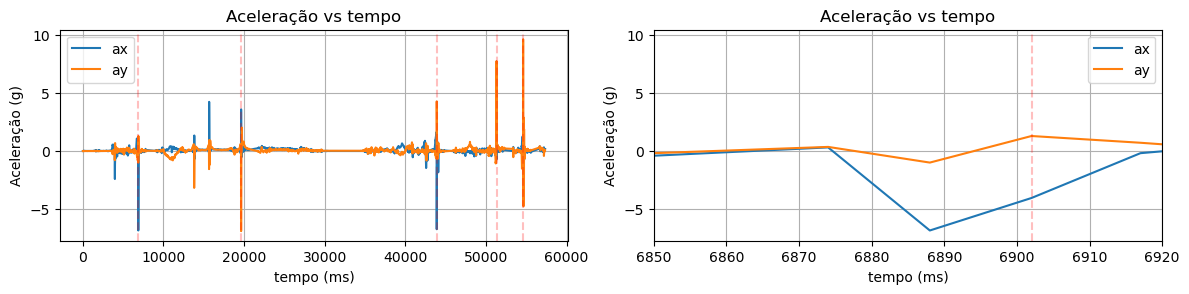


Time differences between |a| > 5g and col rising edge (in ms):
Δt = 14.00 ms (exceed at 6888.00 ms, col=1 at 6902.00 ms)
Δt = 14.00 ms (exceed at 19638.00 ms, col=1 at 19652.00 ms)
Δt = 15.00 ms (exceed at 43893.00 ms, col=1 at 43908.00 ms)
Δt = 15.00 ms (exceed at 51307.00 ms, col=1 at 51322.00 ms)
Δt = 14.00 ms (exceed at 54610.00 ms, col=1 at 54624.00 ms)


In [49]:
import numpy as np
import matplotlib.pyplot as plt

# Load the data from the file
data = np.loadtxt(r"C:\Users\tiago\OneDrive\0 LEF\3º ano\2S\Projeto Integrador\Ax Ay Az roll pitch time\teste_colisoes.txt")
g = 9.81

# Extract each column
ax = data[:, 0]
ay = data[:, 1]
az = data[:, 2]
roll = data[:, 3]
pitch = data[:, 4]
col = data[:, 5]
time = data[:, 6]

# Normalize accelerations to g
ax_g = ax / (100 * g)
ay_g = ay / (100 * g)

# Detect rising edges: transitions from 0 to 1 in col
rising_edges = np.where((col[:-1] == 0) & (col[1:] == 1))[0] + 1
rising_times = time[rising_edges]

# Plot each vs time
plt.figure(figsize=(12, 8))

plt.subplot(3, 2, 1)
plt.plot(time, ax_g, label='ax')
plt.plot(time, ay_g, label='ay')

# Add vertical dashed lines at each 0 → 1 transition
for t in rising_times:
    plt.axvline(x=t, color='red', linestyle='--', alpha=0.25)

plt.title('Aceleração vs tempo')
plt.xlabel('tempo (ms)')
plt.ylabel('Aceleração (g)')
plt.legend()
plt.grid()

plt.subplot(3, 2, 2)
plt.plot(time, ax_g, label='ax')
plt.plot(time, ay_g, label='ay')

# Add vertical dashed lines at each 0 → 1 transition
for t in rising_times:
    plt.axvline(x=t, color='red', linestyle='--', alpha=0.25)

plt.title('Aceleração vs tempo')
plt.xlabel('tempo (ms)')
plt.ylabel('Aceleração (g)')
plt.xlim(6850, 6920)
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# --- Compute time deltas between acceleration spikes and col rising edges ---
# Find indices where |ax| or |ay| exceeds 5g
exceed_mask = (np.abs(ax_g) > 5) | (np.abs(ay_g) > 5)
exceed_indices = np.where(exceed_mask)[0]
exceed_times = time[exceed_indices]

# Print time differences
print("\nTime differences between |a| > 5g and col rising edge (in ms):")
for rt in rising_times:
    previous_exceeds = exceed_times[exceed_times < rt]
    if previous_exceeds.size > 0:
        last_exceed_time = previous_exceeds[-1]
        delta_t = rt - last_exceed_time
        print(f"Δt = {delta_t:.2f} ms (exceed at {last_exceed_time:.2f} ms, col=1 at {rt:.2f} ms)")
    else:
        print(f"No acceleration > 5g before col=1 at {rt:.2f} ms")


Col 2 em 10323.00 ms, roll atravessa zero em 10717.00 ms, Δt = 394.00 ms
Col 2 em 12432.00 ms, roll atravessa zero em 13362.00 ms, Δt = 930.00 ms
Col 2 em 22660.00 ms, roll atravessa zero em 22838.00 ms, Δt = 178.00 ms
Col 2 em 30004.00 ms, roll atravessa zero em 30266.00 ms, Δt = 262.00 ms
Col 2 em 32111.00 ms, roll atravessa zero em 32579.00 ms, Δt = 468.00 ms


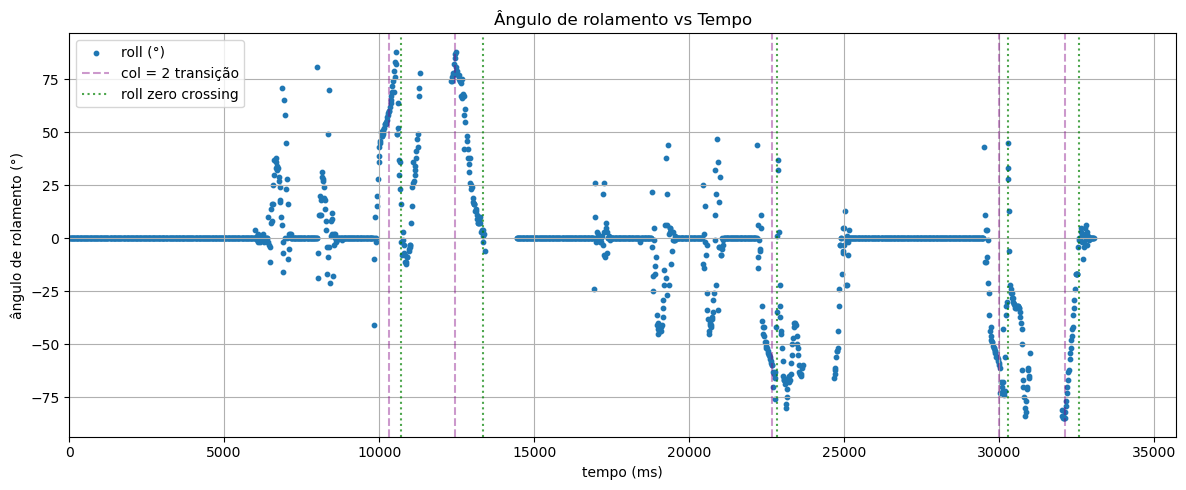

In [73]:
import numpy as np
import matplotlib.pyplot as plt

# Load the data
data = np.loadtxt(r"C:\Users\tiago\OneDrive\0 LEF\3º ano\2S\Projeto Integrador\Ax Ay Az roll pitch time\Avaliaçao_tumble.txt")
g = 9.81

# Extract columns
ax = data[:, 0]
ay = data[:, 1]
az = data[:, 2]
pitch = data[:, 3]
roll = data[:, 4]
col = data[:, 5]
time = data[:, 6]

# --- Shift time to start at t = 0 ---
time = time - time[0] - 20000

# Detect when col goes from not-2 to 2 (rising to 2)
col_to_2_edges = np.where((col[:-1] != 2) & (col[1:] == 2))[0] + 1
col2_times = time[col_to_2_edges]

# Para armazenar os tempos de crossing do roll após col = 2
roll_crossings_times = []

# Detectar crossings de zero no roll após cada col_to_2 event
for idx in col_to_2_edges:
    t_start = time[idx]

    crossing_idx = None
    for i in range(idx + 1, len(roll)):
        if (roll[i - 1] <= 0 < roll[i]) or (roll[i - 1] >= 0 > roll[i]):
            crossing_idx = i
            break

    if crossing_idx is not None:
        t_cross = time[crossing_idx]
        delta_t = t_cross - t_start
        roll_crossings_times.append(t_cross)
        print(f"Col 2 em {t_start:.2f} ms, roll atravessa zero em {t_cross:.2f} ms, Δt = {delta_t:.2f} ms")
    else:
        print(f"Col 2 em {t_start:.2f} ms, roll NÃO atravessa zero depois desse evento.")

# Plot roll vs time and vertical lines at col == 2 transitions + crossings
plt.figure(figsize=(12, 5))
plt.scatter(time, roll, label='roll (°)', s=10)
for t in col2_times:
    plt.axvline(x=t, color='purple', linestyle='--', alpha=0.4, label='col = 2 transição' if t == col2_times[0] else "")
for t_cross in roll_crossings_times:
    plt.axvline(x=t_cross, color='green', linestyle=':', alpha=0.7, label='roll zero crossing' if t_cross == roll_crossings_times[0] else "")

plt.title('Ângulo de rolamento vs Tempo')
plt.xlabel('tempo (ms)')
plt.ylabel('ângulo de rolamento (°)')
plt.xlim(0)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()


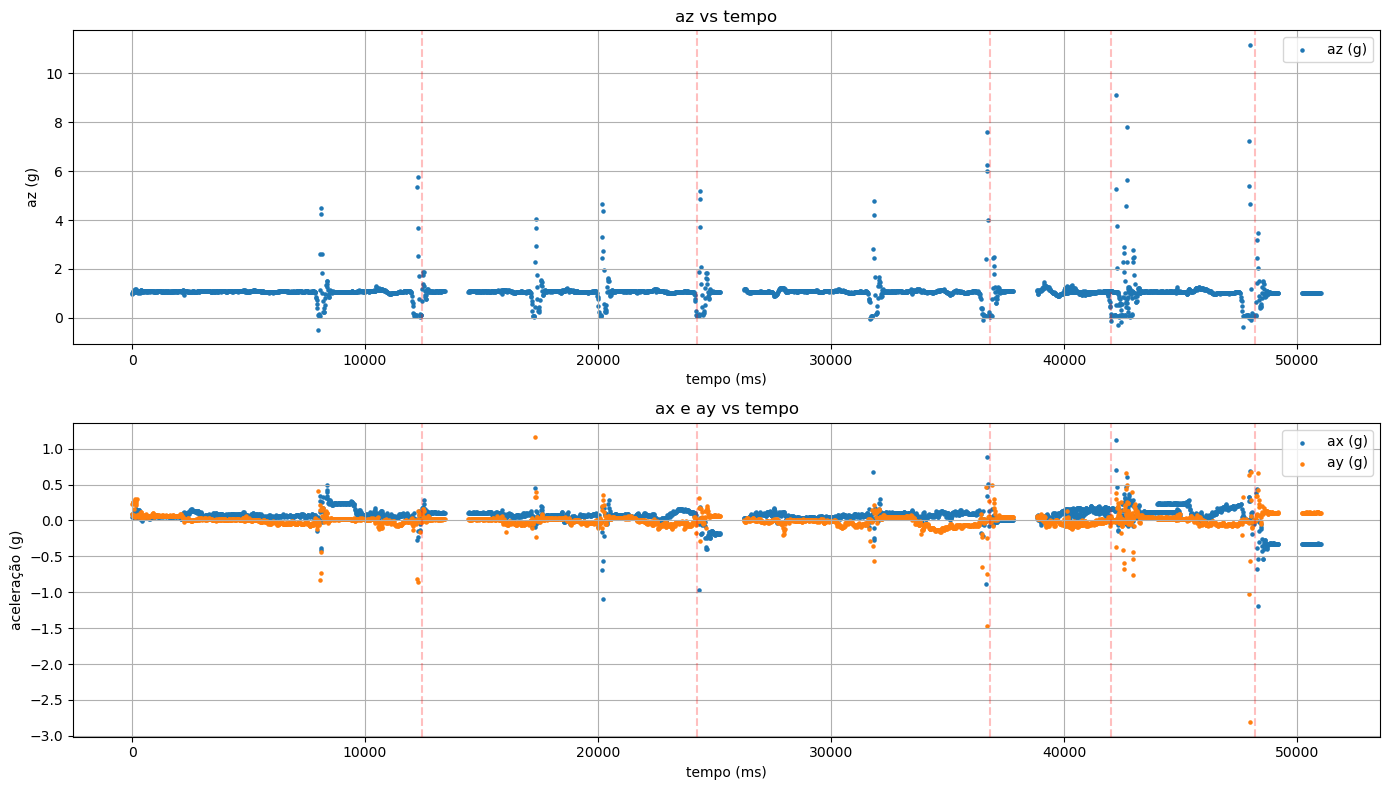

In [113]:
import numpy as np
import matplotlib.pyplot as plt

# Load the data
data = np.loadtxt(r"C:\Users\tiago\OneDrive\0 LEF\3º ano\2S\Projeto Integrador\Ax Ay Az roll pitch time\aval_3_queda.txt")
g = 9.81

# Extract columns
ax = data[:, 0]
ay = data[:, 1]
az = data[:, 2]
pitch = data[:, 3]
roll = data[:, 4]
col = data[:, 5]
time = data[:, 6]

# --- Shift times after 45000 ms by subtracting 5000 ms ---
time_shifted = np.copy(time)
mask_after_45000 = time > 45000
time_shifted[mask_after_45000] = time_shifted[mask_after_45000] - 5000

# Detect rising edges from 0 to 3 (col 0 → 3)
col_0_to_3 = np.where((col[:-1] == 0) & (col[1:] == 3))[0] + 1
times_0_to_3 = time_shifted[col_0_to_3]

# Detect rising edges from 0 to 1 (col 0 → 1)
col_0_to_1 = np.where((col[:-1] == 0) & (col[1:] == 1))[0] + 1
times_0_to_1 = time_shifted[col_0_to_1]

# Plotting
plt.figure(figsize=(14, 8))

# Subplot 1: az vs time with scatter
plt.subplot(2, 1, 1)
plt.scatter(time_shifted, az / (100 * g), s=5, label='az (g)')
for t in times_0_to_3:
    plt.axvline(x=t, color='red', linestyle='--', alpha=0.25)
for t in times_0_to_1:
    plt.axvline(x=t, color='purple', linestyle='--', alpha=0.25)
plt.title('az vs tempo')
plt.xlabel('tempo (ms)')
plt.ylabel('az (g)')
plt.grid()
plt.legend()

# Subplot 2: ax and ay vs time with scatter
plt.subplot(2, 1, 2)
plt.scatter(time_shifted, ax / (100 * g), s=5, label='ax (g)')
plt.scatter(time_shifted, ay / (100 * g), s=5, label='ay (g)')
for t in times_0_to_3:
    plt.axvline(x=t, color='red', linestyle='--', alpha=0.25)
for t in times_0_to_1:
    plt.axvline(x=t, color='purple', linestyle='--', alpha=0.25)
plt.title('ax e ay vs tempo')
plt.xlabel('tempo (ms)')
plt.ylabel('aceleração (g)')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()


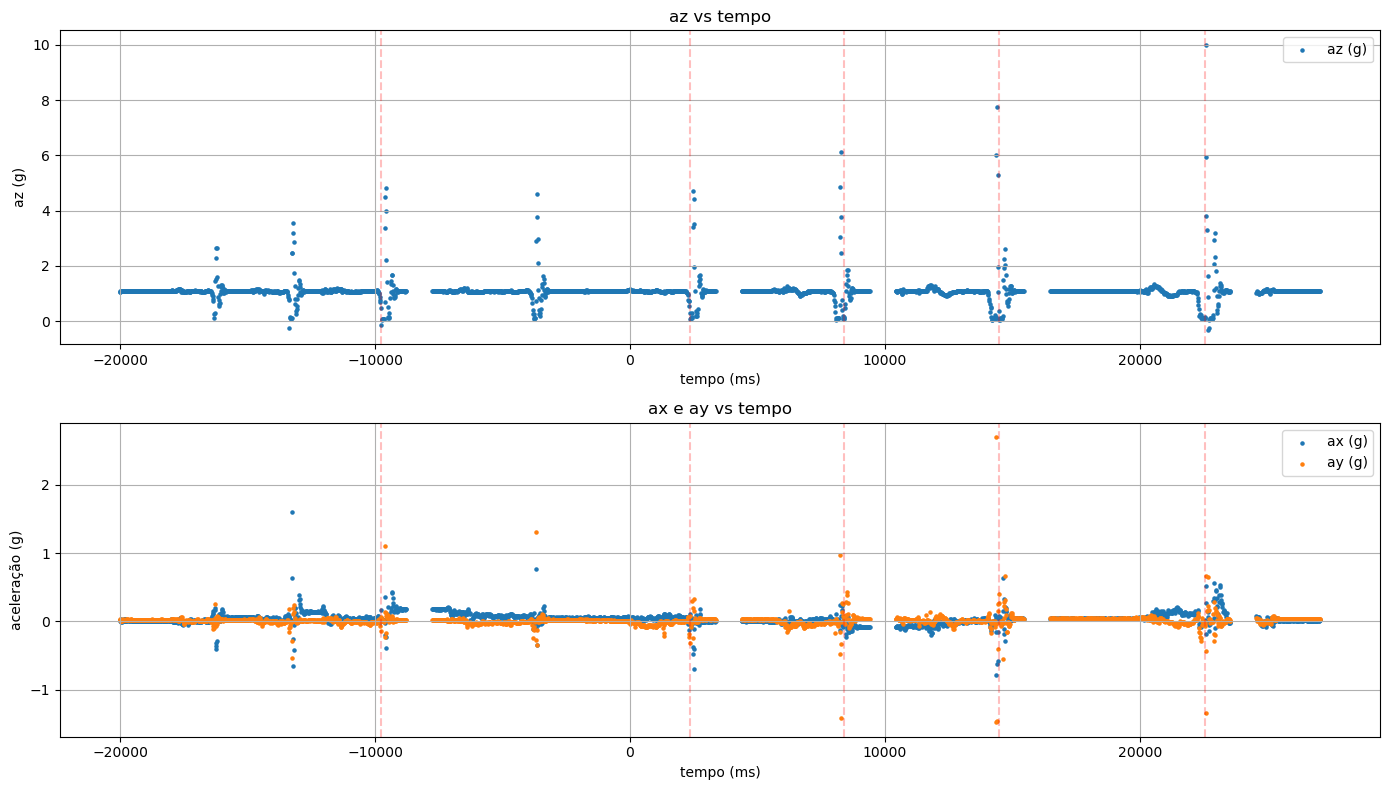

In [115]:
import numpy as np
import matplotlib.pyplot as plt

# Load the data
data = np.loadtxt(r"C:\Users\tiago\OneDrive\0 LEF\3º ano\2S\Projeto Integrador\Ax Ay Az roll pitch time\aval_4_queda.txt")
g = 9.81

# Extract columns
ax = data[:, 0]
ay = data[:, 1]
az = data[:, 2]
pitch = data[:, 3]
roll = data[:, 4]
col = data[:, 5]
time = data[:, 6]

# --- Shift time to start at t = 0 ---
time = time - time[0] - 20000

# Detect rising edges from 0 to 3 (col 0 → 3)
col_0_to_3 = np.where((col[:-1] == 0) & (col[1:] == 3))[0] + 1
times_0_to_3 = time[col_0_to_3]

# Detect rising edges from 0 to 1 (col 0 → 1)
col_0_to_1 = np.where((col[:-1] == 0) & (col[1:] == 1))[0] + 1
times_0_to_1 = time[col_0_to_1]

# Plotting
plt.figure(figsize=(14, 8))

# Subplot 1: az vs time with scatter
plt.subplot(2, 1, 1)
plt.scatter(time, az / (100 * g), s=5, label='az (g)')
for t in times_0_to_3:
    plt.axvline(x=t, color='red', linestyle='--', alpha=0.25)
for t in times_0_to_1:
    plt.axvline(x=t, color='purple', linestyle='--', alpha=0.25)
plt.title('az vs tempo')
plt.xlabel('tempo (ms)')
plt.ylabel('az (g)')
plt.grid()
plt.legend()

# Subplot 2: ax and ay vs time with scatter
plt.subplot(2, 1, 2)
plt.scatter(time, ax / (100 * g), s=5, label='ax (g)')
plt.scatter(time, ay / (100 * g), s=5, label='ay (g)')
for t in times_0_to_3:
    plt.axvline(x=t, color='red', linestyle='--', alpha=0.25)
for t in times_0_to_1:
    plt.axvline(x=t, color='purple', linestyle='--', alpha=0.25)
plt.title('ax e ay vs tempo')
plt.xlabel('tempo (ms)')
plt.ylabel('aceleração (g)')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()


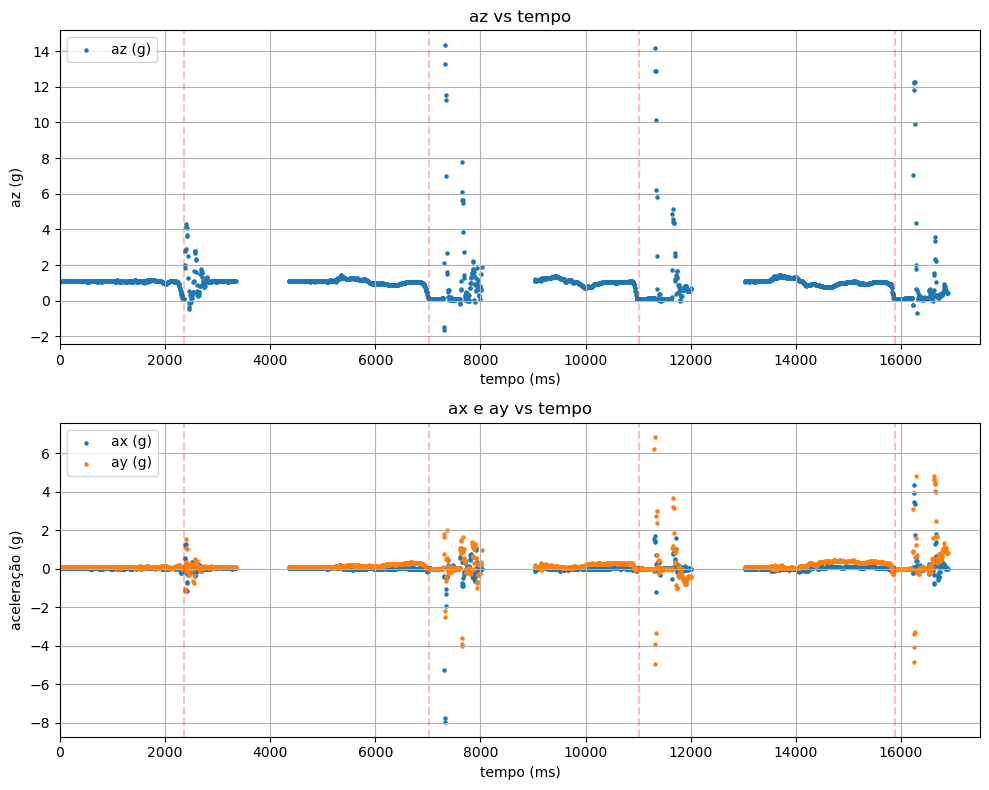

Evento 1: Δt = 41.00 ms
Evento 2: Δt = 303.00 ms
Evento 3: Δt = 308.00 ms
Evento 4: Δt = 372.00 ms


In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Load the data
data = np.loadtxt(r"C:\Users\tiago\OneDrive\0 LEF\3º ano\2S\Projeto Integrador\Ax Ay Az roll pitch time\quedas_new.txt")
g = 9.81

# Extract columns
ax = data[:, 0]
ay = data[:, 1]
az = data[:, 2]
pitch = data[:, 3]
roll = data[:, 4]
col = data[:, 5]
time = data[:, 6]

# --- Shift time to start at t = 0 ---
time = time - time[0]

# Detect rising edges from 0 to 3 (col 0 → 3)
col_0_to_3 = np.where((col[:-1] == 0) & (col[1:] == 3))[0] + 1
times_0_to_3 = time[col_0_to_3]

# Detect rising edges from 0 to 1 (col 0 → 1)
col_0_to_1 = np.where((col[:-1] == 0) & (col[1:] == 1))[0] + 1
times_0_to_1 = time[col_0_to_1]

# Plotting
plt.figure(figsize=(10, 8))

# Subplot 1: az vs time with scatter
plt.subplot(2, 1, 1)
plt.scatter(time, az / (100 * g), s=5, label='az (g)')
for t in times_0_to_3:
    plt.axvline(x=t, color='red', linestyle='--', alpha=0.25)
for t in times_0_to_1:
    plt.axvline(x=t, color='purple', linestyle='--', alpha=0.25)
plt.title('az vs tempo')
plt.xlabel('tempo (ms)')
plt.ylabel('az (g)')
plt.xlim(0, 17500)
plt.grid()
plt.legend()

# Subplot 2: ax and ay vs time with scatter
plt.subplot(2, 1, 2)
plt.scatter(time, ax / (100 * g), s=5, label='ax (g)')
plt.scatter(time, ay / (100 * g), s=5, label='ay (g)')
for t in times_0_to_3:
    plt.axvline(x=t, color='red', linestyle='--', alpha=0.25)
for t in times_0_to_1:
    plt.axvline(x=t, color='purple', linestyle='--', alpha=0.25)
plt.title('ax e ay vs tempo')
plt.xlabel('tempo (ms)')
plt.ylabel('aceleração (g)')
plt.xlim(0, 17500)
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

# Lista para armazenar os deltas de tempo
delta_times = []

# Para cada instante em que col vai de 0 para 3
for t_start in times_0_to_3:
    # Encontrar o índice correspondente ao instante t_start
    idx_start = np.searchsorted(time, t_start)
    
    # Definir o intervalo de 1000 ms após o t_start
    t_end = t_start + 1000
    idx_end = np.searchsorted(time, t_end)

    # Garantir que não estamos extrapolando os limites do array
    if idx_end > len(time):
        idx_end = len(time)

    # Extrair o segmento de az e tempo nesse intervalo
    az_segment = az[idx_start:idx_end]
    time_segment = time[idx_start:idx_end]

    if len(az_segment) > 0:
        # Encontrar o índice do valor máximo de |az| nesse segmento
        max_idx = np.argmax(np.abs(az_segment))
        t_max = time_segment[max_idx]

        # Calcular a diferença de tempo e adicionar à lista
        delta_t = t_max - t_start
        delta_times.append(delta_t)

# Exibir os resultados
for i, dt in enumerate(delta_times):
    print(f"Evento {i+1}: Δt = {dt:.2f} ms")

